In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from nltk.probability import FreqDist
import pymorphy3

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [4]:
with open('2019.txt', 'r') as file:
    data = file.read()

In [9]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [11]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [13]:
tokenized = tokenize_text(data)

In [15]:
all_words = FreqDist(tokenized)

In [17]:
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('брикс', 244), ('страна', 173), ('встреча', 92), ('вопрос', 75), ('сотрудничество', 51), ('министр', 48), ('группа', 46), ('гбразилиа', 43), ('также', 43), ('международный', 42), ('развитие', 39), ('область', 39), ('заседание', 36), ('оон', 36), ('приветствовать', 35), ('рабочий', 35), ('цель', 34), ('который', 32), ('отмечать', 31), ('октябрь', 31), ('год', 28), ('итог', 28), ('безопасность', 28), ('рамка', 28), ('подчёркивать', 27), ('государство', 26), ('усилие', 25), ('совместный', 24), ('ноябрь', 23), ('наш', 23), ('торговля', 23), ('новый', 23), ('банк', 23), ('создание', 23), ('исследование', 23), ('важность', 23), ('экономический', 22), ('сфера', 22), ('совет', 22), ('борьба', 22), ('вновь', 22), ('включая', 21), ('организация', 21), ('заявлять', 19), ('терроризм', 18), ('сентябрь', 18), ('обмен', 17), ('обеспечение', 17), ('связь', 17), ('устойчивый', 17), ('использование', 17), ('рост', 16), ('технология', 16), ('проведение', 16), ('инвестиция',

C:\Temp\ipykernel_11732\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


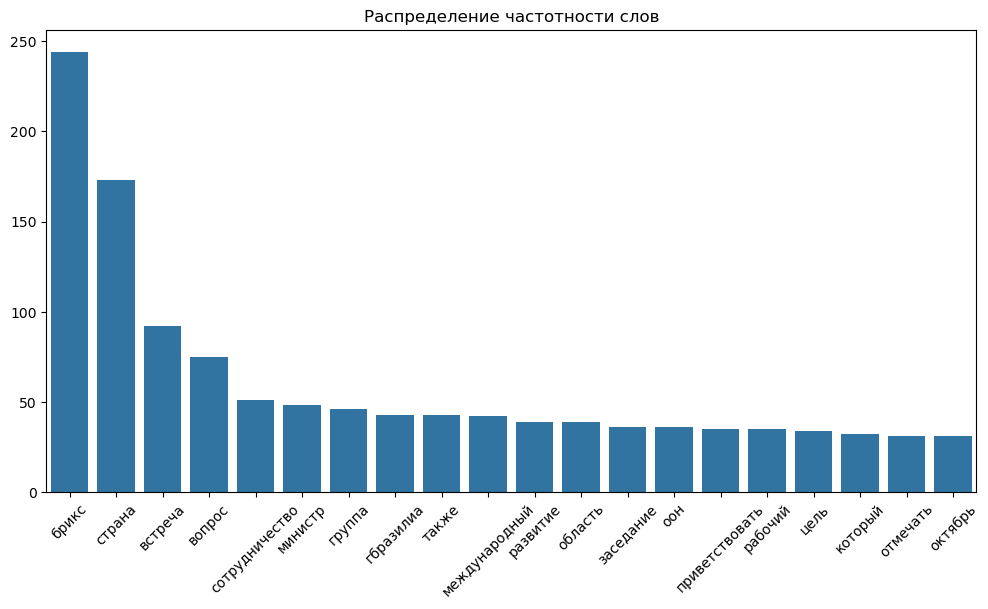

In [19]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [21]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [23]:
tokens = stop_words_extra(tokenized)

C:\Temp\ipykernel_11732\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


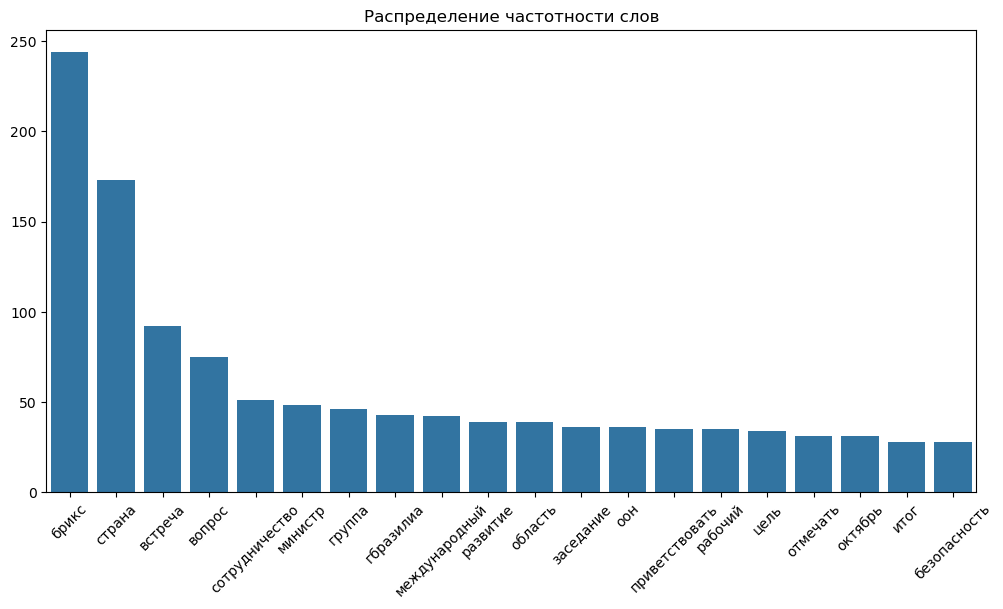

In [25]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [27]:
textt = ','.join(w for w in tokens)

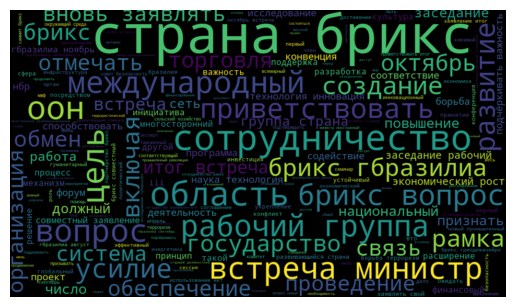

In [29]:
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [31]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [34]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [35]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['октябрь', 'приветствовать', 'оон', 'развитие', 'гбразилиа', 'группа', 'министр', 'встреча', 'страна', 'брикс']


Top 10 words for topic #1:
['рамка', 'итог', 'отмечать', 'цель', 'рабочий', 'заседание', 'область', 'международный', 'сотрудничество', 'вопрос']




In [36]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['торговля', 'создание', 'важность', 'подчёркивать', 'безопасность', 'оон', 'развитие', 'гбразилиа', 'группа', 'министр']


Top 10 words for topic #1:
['банк', 'ноябрь', 'совместный', 'государство', 'рамка', 'итог', 'рабочий', 'международный', 'сотрудничество', 'вопрос']


Top 10 words for topic #2:
['усилие', 'октябрь', 'отмечать', 'цель', 'приветствовать', 'заседание', 'область', 'встреча', 'страна', 'брикс']




Вывод: тематика декларации 2019 г. посвящена общим вопросам международного сотрудничества